<a href="https://colab.research.google.com/github/iceik973-dotcom/ML1/blob/main/%D0%9B%D0%A04_%D0%9C%D0%9D_%D0%93%D1%80%D0%B8%D0%B3%D0%BE%D1%80%D0%B8%D1%88%D0%B5%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    )

## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [2]:
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df = pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))

display(df.head())

Using Colab cache for faster access to the 'car-price-prediction' dataset.


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


**car_ID**-Унікальний ідентифікатор автомобіл

**symboling** - Категорія страхового ризику автомобіля

**CarName** - Марка та модель автомобіля

**fueltype**-Тип пального (gas, diesel)

**aspiration** - Тип подачі повітря до двигуна: стандартний або турбований

**doornumber** - Кількість дверей

**carbody** - Тип кузова автомобіля

**drivewheel**-Тип приводу: передній, задній або повний

**enginelocation** - Розташування двигунаwheelbaseКолісна база автомобіля

**carlength** - Довжина автомобіля

**carwidth** - Ширина автомобіля

**carheight** -Висота автомобіля

**curbweight** - Споряджена маса автомобіля

**enginetype** - Тип двигуна

**cylindernumbe** - Кількість циліндрів

**enginesize** - Робочий об'єм/розмір двигуна

**fuelsystem** - Тип паливної системи

**boreratio** - Діаметр циліндра / характеристика отвору циліндра

**stroke** - Хід поршня

**compressionratio** - Ступінь стиснення двигуна

**horsepower**- Потужність двигуна

**peakrpm** - Максимальна частота обертання двигуна

**citympg**- Паливна економічність під час руху містом

**highwaympg **- Паливна економічність на шосе

**price**- Ціна автомобіля — цільова змінна

In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

Висновок: Датасет містить 205 автомобілів і 26 ознак. Дані охоплюють технічні характеристики автомобілів та їхню ціну, тому датасет придатний для побудови моделей прогнозування вартості.


## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [4]:
print("Кількість пропущених значень:")
display(df.isna().sum().sort_values(ascending=False))

print("Повні дублікати:", df.duplicated().sum())
print(
    "Дублікати без урахування car_ID:",
    df.drop(columns="car_ID").duplicated().sum()
)

Кількість пропущених значень:


,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


Повні дублікати: 0
Дублікати без урахування car_ID: 0


Висновок: У датасеті немає пропущених значень і дублікатів. Отже, додаткове заповнення пропусків або видалення повторних записів на цьому етапі не потрібні.


## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [5]:
df['CarName'].value_counts()

,count
CarName,
peugeot 504,6
toyota corolla,6
toyota corona,6
subaru dl,4
mitsubishi outlander,3
...,...
volkswagen super beetle,1
volkswagen rabbit custom,1
volvo 245,1


In [6]:
ids = df["car_ID"].copy()

df_model = df.copy()
df_model["brand"] = (
    df_model["CarName"]
    .str.lower()
    .str.split()
    .str[0]
    .replace({
        "maxda": "mazda",
        "porcshce": "porsche",
        "toyouta": "toyota",
        "vokswagen": "volkswagen",
        "vw": "volkswagen",
    })
)
df_model = df_model.drop(columns=["car_ID", "CarName"])

In [7]:
df_model

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,-1,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,-1,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


Висновок: Ідентифікатор car_ID було збережено окремо, а назву автомобіля перетворено на ознаку brand. Помилки в окремих назвах брендів також було виправлено, що підготувало дані до подальшого моделювання.


## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


,skewness
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,-0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997


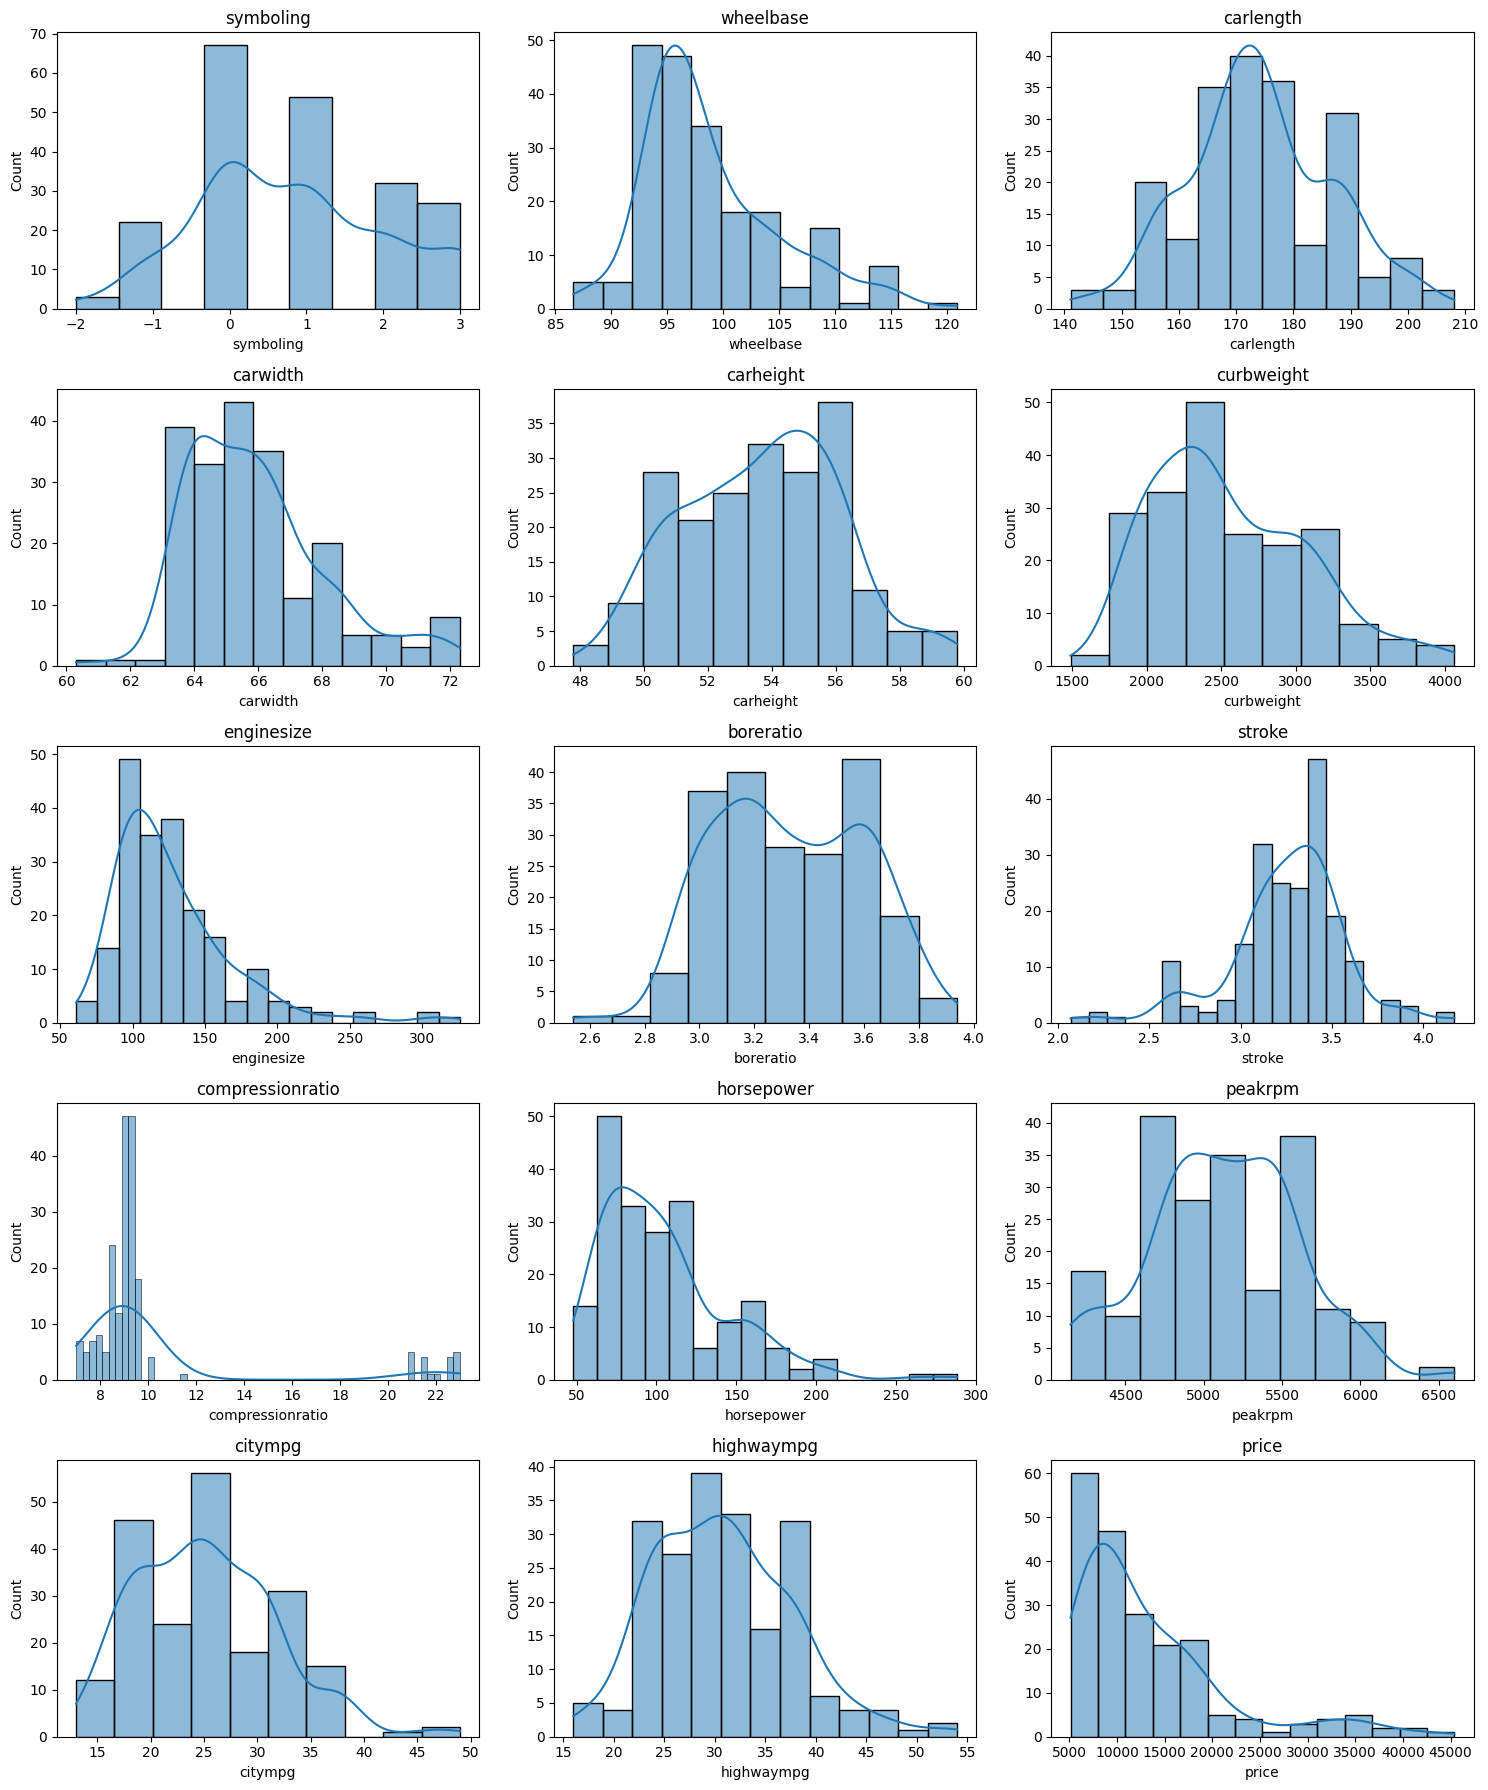

In [8]:
numeric_initial = df_model.select_dtypes(include=np.number).columns

skew_initial = df_model[numeric_initial].skew().sort_values(key=np.abs, ascending=False)

display(skew_initial.to_frame("skewness"))

n_cols = 3
n_rows = int(np.ceil(len(numeric_initial) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.6 * n_rows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, numeric_initial):
    sns.histplot(df_model[col], kde=True, ax=ax)
    ax.set_title(col)
for ax in axes[len(numeric_initial):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Висновок: Частина числових ознак має помітну асиметрію розподілу. Найбільша асиметрія спостерігається для compressionratio, enginesize, price та horsepower, тому перед моделюванням доцільно застосувати трансформацію числових ознак.


## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [9]:
X = df_model.drop(columns="price")

y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

id_train = ids.loc[X_train.index]
id_test = ids.loc[X_test.index]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (164, 24) Test: (41, 24)


Висновок: Дані було поділено на навчальну та тестову вибірки у співвідношенні 80/20. У навчальній вибірці залишилося 164 записи, а в тестовій — 41, при цьому car_ID збережено окремо для ідентифікації автомобілів.


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [10]:
continuous_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c != "symboling"
]

q1 = X_train[continuous_cols].quantile(0.25)

q3 = X_train[continuous_cols].quantile(0.75)

iqr = q3 - q1
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

outlier_counts = (
    (X_train[continuous_cols].lt(lower_bounds)) |
    (X_train[continuous_cols].gt(upper_bounds))
).sum().sort_values(ascending=False)

display(outlier_counts.to_frame("potential_outliers_train"))

X_train = X_train.copy()
X_test = X_test.copy()

X_train[continuous_cols] = X_train[continuous_cols].clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1
)

X_test[continuous_cols] = X_test[continuous_cols].clip(
    lower=lower_bounds,
    upper=upper_bounds,
    axis=1
)

,potential_outliers_train
compressionratio,20
stroke,16
carwidth,10
horsepower,7
enginesize,7
wheelbase,6
peakrpm,2
highwaympg,1
boreratio,1
curbweight,0


Висновок: Методом IQR було виявлено потенційні викиди в кількох числових ознаках. Межі визначалися лише за навчальною вибіркою, після чого значення було обмежено цими межами для зменшення впливу крайніх спостережень.


## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


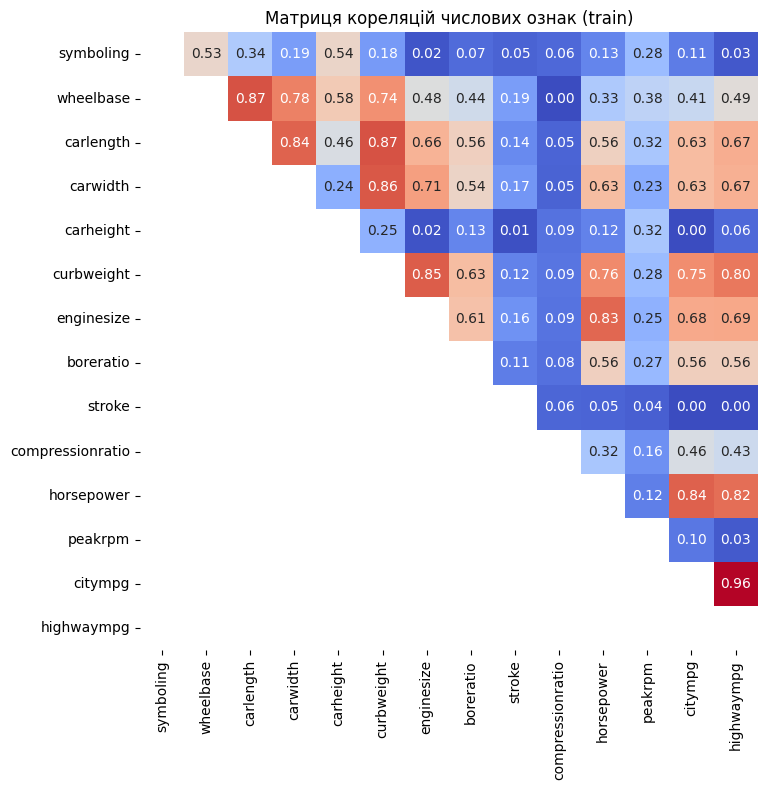

Сильно корельовані пари (|r| > 0.85):
wheelbase - carlength: 0.867
carlength - curbweight: 0.866
carwidth - curbweight: 0.858
citympg - highwaympg: 0.964
Ознаки для видалення: ['carlength', 'carwidth', 'citympg', 'wheelbase']


In [11]:
numeric_train_cols = X_train.select_dtypes(include=np.number).columns

corr = X_train[numeric_train_cols].corr().abs()
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    mask=np.tril(np.ones_like(corr, dtype=bool)),
    square=True,
    cbar=False,
)

plt.title("Матриця кореляцій числових ознак (train)")
plt.tight_layout()
plt.show()

target_corr = pd.concat(
    [
        X_train[numeric_train_cols],
        y_train.rename("price")
    ],
    axis=1
).corr(numeric_only=True)["price"].abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
pairs = []

for col in upper.columns:
    for row in upper.index[upper[col] > 0.85]:
        pairs.append(
            (row, col, upper.loc[row, col])
        )
features_to_drop = set()

for a, b, r in pairs:

    if target_corr[a] < target_corr[b]:
        features_to_drop.add(a)
    else:
        features_to_drop.add(b)

print("Сильно корельовані пари (|r| > 0.85):")
for a, b, r in pairs:
    print(f"{a} - {b}: {r:.3f}")

print("Ознаки для видалення:", sorted(features_to_drop))

X_train = X_train.drop(
    columns=list(features_to_drop)
)

X_test = X_test.drop(
    columns=list(features_to_drop)
)

Висновок: Виявлено кілька пар сильно корельованих ознак, зокрема citympg і highwaympg з кореляцією 0,964. Для зменшення мультиколінеарності було вилучено carlength, carwidth, citympg та wheelbase.


## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [12]:
continuous_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c != "symboling"
]

ordinal_numeric_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if c == "symboling"
]

categorical_cols = (
    X_train
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

numeric_pipeline = Pipeline(steps=[
    ("power", PowerTransformer(
        method="yeo-johnson",
        standardize=False
    )),
    ("scaler", StandardScaler()),
])

ordinal_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", numeric_pipeline, continuous_cols),
        ("ordinal", ordinal_pipeline, ordinal_numeric_cols),
        ("categorical", categorical_pipeline, categorical_cols),
    ],

    remainder="drop",
    verbose_feature_names_out=False,
)

num_check = clone(numeric_pipeline)

num_train_transformed = pd.DataFrame(
    num_check.fit_transform(
        X_train[continuous_cols]
    ),
    columns=continuous_cols,
    index=X_train.index,
)

skewness_after = (
    num_train_transformed
    .skew()
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

display(
    skewness_after.to_frame("skewness_after")
)

,skewness_after
horsepower,0.066280
curbweight,0.049894
enginesize,0.044834
stroke,0.015846
highwaympg,-0.012188
boreratio,-0.005941
carheight,-0.005170
compressionratio,0.004872
peakrpm,-0.003589


Висновок: Числові, дискретні та категоріальні ознаки було оброблено окремими етапами. Для неперервних числових ознак використано Yeo-Johnson і стандартизацію, для symboling — стандартизацію, а для категоріальних ознак — One-Hot Encoding.


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [13]:
num_check = clone(numeric_pipeline)

num_train_transformed = pd.DataFrame(
    num_check.fit_transform(
        X_train[continuous_cols]
    ),
    columns=continuous_cols,
    index=X_train.index,
)

skewness_after = (
    num_train_transformed
    .skew()
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

display(
    skewness_after.to_frame("skewness_after")
)

,skewness_after
horsepower,0.066280
curbweight,0.049894
enginesize,0.044834
stroke,0.015846
highwaympg,-0.012188
boreratio,-0.005941
carheight,-0.005170
compressionratio,0.004872
peakrpm,-0.003589


Висновок: Після застосування Yeo-Johnson асиметрія більшості неперервних числових ознак стала близькою до нуля. Це свідчить про те, що трансформація ефективно зменшила перекіс розподілів.


## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [14]:
estimators = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(
        alpha=1.0
    ),
    "Lasso": Lasso(
        alpha=1.0,
        max_iter=20000
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "SVR": SVR(),
}
models = {
    name: Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", estimator),
        ])
    for name, estimator in estimators.items()
}

Висновок: Було побудовано шість моделей регресії: Linear Regression, Ridge, Lasso, Random Forest, Gradient Boosting та SVR. Такий набір дає змогу порівняти як лінійні, так і нелінійні підходи до прогнозування ціни.


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


In [15]:
results = []
predictions = {}
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  predictions[name] = y_pred
  results.append({
      "Model": name,
      "R²": r2_score(
        y_test,
        y_pred
    ),
      "MAE": mean_absolute_error(
        y_test,
        y_pred
    ),
      "MSE": mean_squared_error(
        y_test,
        y_pred
    ),
      "MAPE, %": mean_absolute_percentage_error(
        y_test,
        y_pred
    ) * 100,
})
  results_df = (
    pd.DataFrame(results)
    .sort_values(
        "R²",
        ascending=False
    )
    .reset_index(drop=True)
)

  display(results_df)

,Model,R²,MAE,MSE,"MAPE, %"
0,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447


,Model,R²,MAE,MSE,"MAPE, %"
0,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
1,Ridge,0.853789,2367.223583,1.154249e+07,18.193087


,Model,R²,MAE,MSE,"MAPE, %"
0,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
1,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
2,Ridge,0.853789,2367.223583,1.154249e+07,18.193087


,Model,R²,MAE,MSE,"MAPE, %"
0,Random Forest,0.954906,1318.781760,3.559886e+06,9.695253
1,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
2,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
3,Ridge,0.853789,2367.223583,1.154249e+07,18.193087


,Model,R²,MAE,MSE,"MAPE, %"
0,Random Forest,0.954906,1318.781760,3.559886e+06,9.695253
1,Gradient Boosting,0.930420,1727.403684,5.492942e+06,12.050186
2,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
3,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
4,Ridge,0.853789,2367.223583,1.154249e+07,18.193087


,Model,R²,MAE,MSE,"MAPE, %"
0,Random Forest,0.954906,1318.781760,3.559886e+06,9.695253
1,Gradient Boosting,0.930420,1727.403684,5.492942e+06,12.050186
2,Linear Regression,0.879431,2156.098245,9.518236e+06,16.376447
3,Lasso,0.878234,2105.214295,9.612671e+06,15.133568
4,Ridge,0.853789,2367.223583,1.154249e+07,18.193087
5,SVR,-0.099732,5696.776966,8.681724e+07,36.027666


Висновок: За результатами тестування найвищий R² показала модель Random Forest — 0,9549, а найменші MAE та MAPE також отримано для неї: 1318,78 та 9,70% відповідно. SVR показала найгірші результати з R² = −0,0997 та MAPE = 36,03%.


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


Модель класифікації, наприклад Logistic Regression, не підходить для безпосереднього прогнозування ціни автомобіля, оскільки вона призначена для задач класифікації — визначення належності об’єкта до певного класу. Її результатом є ймовірність належності до класу або сам клас, а не конкретне неперервне числове значення.

Прогнозування price є задачею регресії, оскільки ціна автомобіля є числовою неперервною величиною і може набувати великої кількості різних значень.

Тому для прогнозування ціни використовуються регресійні моделі, які навчаються встановлювати залежність між характеристиками автомобіля та його ціною. Саме тому моделі, використані в роботі, відповідають поставленій задачі: вони призначені для прогнозування числового значення цільової змінної price.

Висновок: прогнозування ціни автомобіля належить до задач регресії, тому для нього необхідно використовувати регресійні, а не класифікаційні моделі.

## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


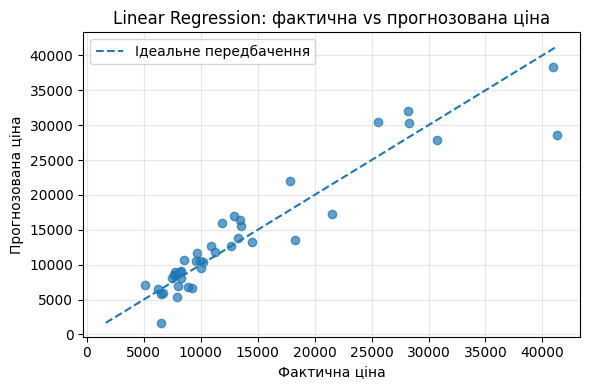

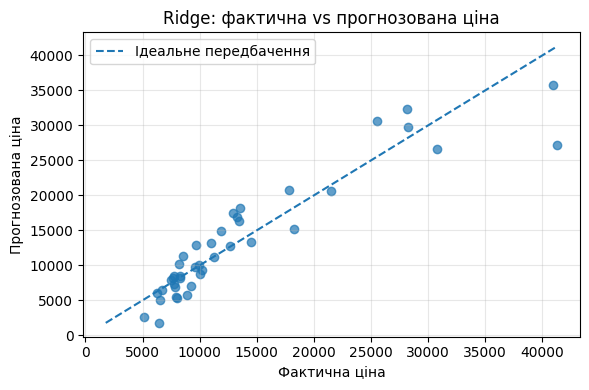

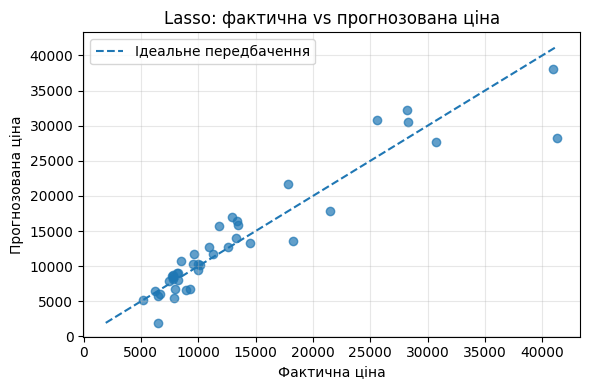

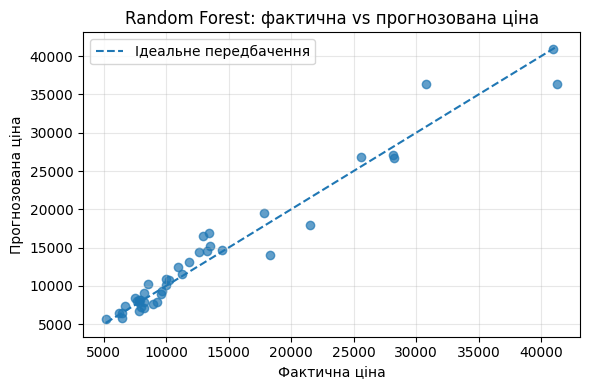

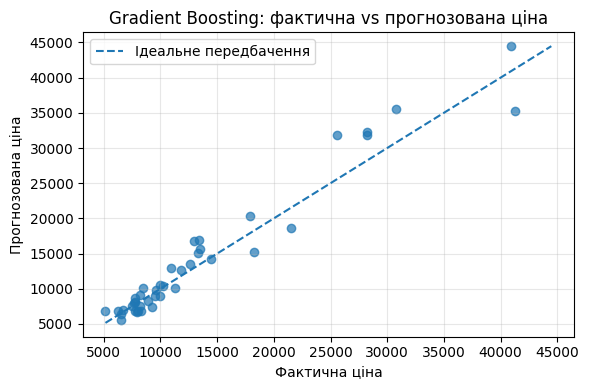

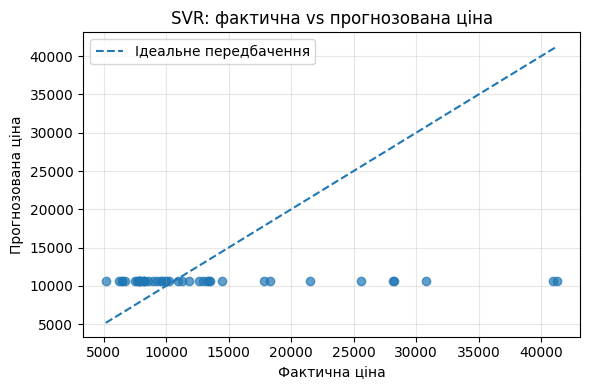

In [16]:
y_true = y_test.to_numpy()

for name, y_pred in predictions.items():
    y_pred = np.asarray(y_pred).ravel()
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([lo, hi], [lo, hi], "--", label="Ідеальне передбачення")
    plt.xlabel("Фактична ціна")
    plt.ylabel("Прогнозована ціна")
    plt.title(f"{name}: фактична vs прогнозована ціна")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Висновок: Графіки фактичних і прогнозованих цін дають змогу візуально оцінити точність моделей. Чим ближче точки розташовані до лінії ідеального передбачення, тим менша різниця між фактичною та прогнозованою ціною.


## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [17]:
rf_model = models["Random Forest"]
sample_idx = X_test.sample(
    n=min(10, len(X_test)),
    random_state=42
).index
sample_pred = rf_model.predict(
    X_test.loc[sample_idx]
)
sample_rf = pd.DataFrame({
    "car_ID": id_test.loc[sample_idx].to_numpy(),
    "Actual price": y_test.loc[sample_idx].to_numpy(),
    "Predicted price (RF)": sample_pred,
})
sample_rf["Absolute error"] = (
    sample_rf["Actual price"]
    - sample_rf["Predicted price (RF)"]
).abs()
sample_rf["Absolute percentage error, %"] = (
    sample_rf["Absolute error"]
    / sample_rf["Actual price"]
    * 100
)
display(sample_rf)

,car_ID,Actual price,Predicted price (RF),Absolute error,"Absolute percentage error, %"
0,26,6692.0,7316.599000,624.599000,9.333518
1,176,9988.0,10940.662000,952.662000,9.538066
2,148,10198.0,10797.708167,599.708167,5.880645
3,17,41315.0,36371.429000,4943.571000,11.965560
4,69,28248.0,26661.713000,1586.287000,5.615573
5,147,7463.0,8367.516333,904.516333,12.120010
6,144,9960.0,10117.517667,157.517667,1.581503
7,85,14489.0,14688.636000,199.636000,1.377845
8,195,12940.0,16470.556000,3530.556000,27.284049
9,160,7788.0,7907.148000,119.148000,1.529892


Висновок: Для 10 автомобілів із тестової вибірки було отримано прогнози Random Forest та розраховано абсолютну й відносну похибки. Це дає змогу оцінити якість прогнозування не лише за загальними метриками, а й для окремих автомобілів.


## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.


## Висновок

У лабораторній роботі було виконано повний цикл підготовки даних і побудови моделей для прогнозування ціни автомобілів. Проведено первинний аналіз датасету, перевірено якість даних, оброблено викиди, досліджено кореляції та виконано відбір ознак. Числові й категоріальні ознаки підготовлено за допомогою відповідних трансформацій.

Для прогнозування побудовано шість регресійних моделей. За результатами оцінювання найкращі показники на тестовій вибірці отримала модель Random Forest: R² = 0,9549, MAE = 1318,78 та MAPE = 9,70%. Також було виконано візуальне порівняння прогнозів і перевірено результати для окремих автомобілів. Отже, поставлені завдання лабораторної роботи виконано, а отримані результати показали можливість ефективного прогнозування вартості автомобілів за їхніми характеристиками.
